Tasks
Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/amazonreviews.tsv',sep='\t')

In [ ]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [ ]:
#checking null values
df.isnull().sum()

,0
label,0
review,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df["label"].value_counts()

,count
label,
neg,5097
pos,4903


In [ ]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

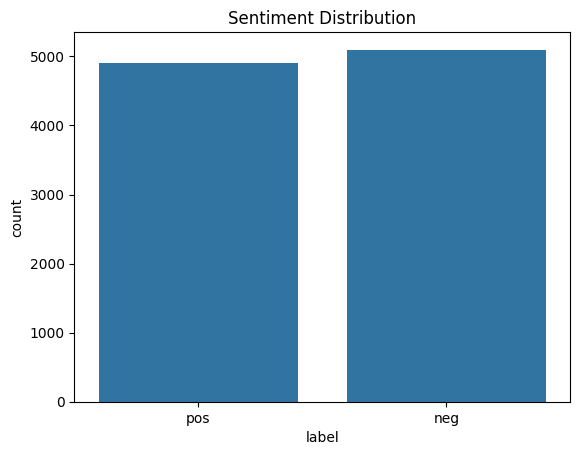

In [ ]:
sns.countplot(data=df, x="label")

plt.title("Sentiment Distribution")

plt.show()

In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#Text Cleaning
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

In [ ]:
corpus = []

for review in df["review"]:

    review = re.sub("[^a-zA-Z]", " ", review)

    review = review.lower()

    review = review.split()

    review = [
        stemmer.stem(word)
        for word in review
        if word not in stop_words
    ]

    review = " ".join(review)

    corpus.append(review)

In [ ]:
df["clean_review"] = corpus

In [ ]:
#Word Cloud
pip install wordcloud

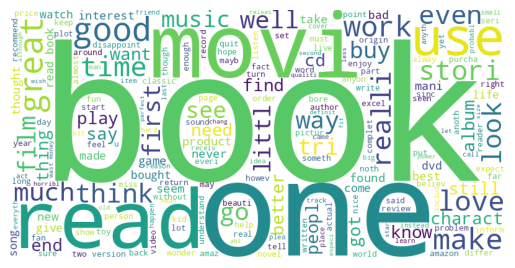

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

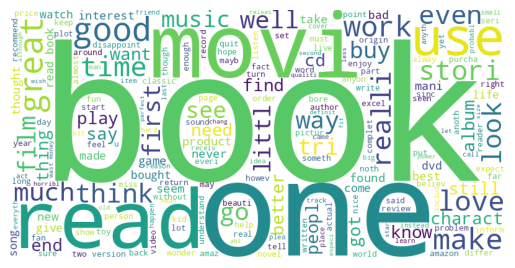

In [ ]:
#positive review
positive = " ".join(
    df[df.label=="pos"]["clean_review"]
)

WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

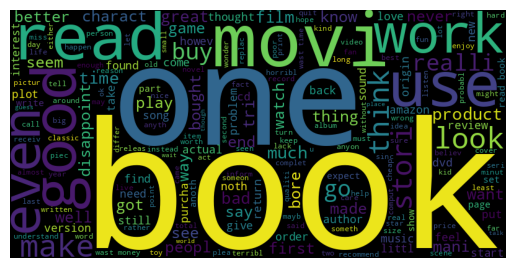

In [ ]:
#negative review
negative = " ".join(
    df[df.label=="neg"]["clean_review"]
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(negative)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [ ]:
#from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"]).toarray()

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df["label"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42
)

In [ ]:
#logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
prediction = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,prediction)

0.853

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1037
           1       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



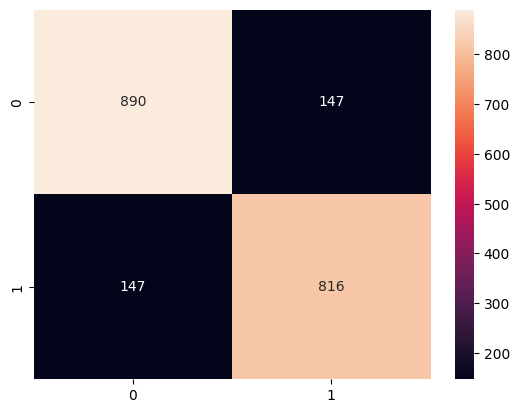

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,prediction)

sns.heatmap(cm,annot=True,fmt="d")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

model,

X,

y,

cv=5,

scoring="accuracy"

)

print(scores)

print(scores.mean())

[0.85   0.825  0.817  0.8305 0.8535]
0.8352


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train,y_train)

prediction = svm.predict(X_test)

#accuracy_score(y_test,prediction)

0.838

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train,y_train)

prediction = nb.predict(X_test)

accuracy_score(y_test,prediction)

0.825

In [ ]:
#Neural Network (ANN)
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

ann = Sequential()

ann.add(Dense(128,

activation="relu",

input_shape=(5000,)))

ann.add(Dense(64,

activation="relu"))

ann.add(Dense(1,

activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann.compile(

optimizer="adam",

loss="binary_crossentropy",

metrics=["accuracy"]
)

In [ ]:
ann.fit(

X_train,

y_train,

epochs=10,

batch_size=32,

validation_split=0.2
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7839 - loss: 0.4615 - val_accuracy: 0.8419 - val_loss: 0.3641
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9273 - loss: 0.1991 - val_accuracy: 0.8275 - val_loss: 0.4186
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9669 - loss: 0.1043 - val_accuracy: 0.8319 - val_loss: 0.5193
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9867 - loss: 0.0492 - val_accuracy: 0.8313 - val_loss: 0.6172
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9975 - loss: 0.0155 - val_accuracy: 0.8294 - val_loss: 0.7562
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9997 - loss: 0.0039 - val_accuracy: 0.8263 - val_loss: 0.8657
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8263 - val_loss: 0.9479
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 6.5523e-04 - val_

In [ ]:
'''this project demonstrates a complete sentiment analysis pipeline using Amazon customer reviews. After cleaning and preprocessing the text, TF-IDF is used to convert reviews into numerical features. Multiple machine learning models such as Logistic Regression, Naive Bayes, SVM, and an Artificial Neural Network are trained and evaluated using accuracy, precision, recall, F1-score, confusion matrix, and cross-validation. Among these, SVM and ANN typically outperform the traditional models, while transformer-based models like BERT generally achieve the highest performance by capturing the contextual meaning of words.'''

'this project demonstrates a complete sentiment analysis pipeline using Amazon customer reviews. After cleaning and preprocessing the text, TF-IDF is used to convert reviews into numerical features. Multiple machine learning models such as Logistic Regression, Naive Bayes, SVM, and an Artificial Neural Network are trained and evaluated using accuracy, precision, recall, F1-score, confusion matrix, and cross-validation. Among these, SVM and ANN typically outperform the traditional models, while transformer-based models like BERT generally achieve the highest performance by capturing the contextual meaning of words.'